# Cluster Analysis of Heart and Lung
This notebook aims to determine features that could possibly explain both variation in heart and lung simulations


In [ ]:
from google.colab import files
import io

uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
# --- Standard Libraries ---
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn ---
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# --- Statistical testing ---
from scipy.stats import kruskal, mannwhitneyu, shapiro

# --- Post-hoc testing ---
try:
    import scikit_posthocs as sp
except ImportError:
    !pip install scikit-posthocs -q
    import scikit_posthocs as sp

# --- Interactive plotting ---
import plotly.express as px
import plotly.graph_objects as go
from scipy.spatial import ConvexHull


## Load and Join Data

In [ ]:
lung = pd.read_csv('patient_lung_sim_results.csv')
heart = pd.read_csv('all_patients_heart_sim_results.csv')

In [ ]:
pe = pd.merge(lung, heart.drop(columns=['HI']), on='patientIndex')

In [ ]:
pe.columns

Index(['patientIndex', 'age', 'gender', 'weight', 'height', 'HI', 'FEV1',
       'FEF2575', 'FVCpct', 'PEFpct', 'FEF2575pct_post', 'LC', 'TC', 'CR',
       'PR', 'Cs', 'Sim_LungVol_Mean', 'Sim_LungVol_Max', 'Sim_LungVol_Std',
       'Sim_TransP_Mean', 'Sim_TransP_Max', 'Sim_TransP_Std',
       'Sim_AlvP_PeakMax', 'Sim_AlvP_PeakMin', 'Sim_Flow_PeakMax',
       'Sim_Flow_Std', 'Sim_DeadFlow_PeakMax', 'Sim_DeadFlow_Std',
       'Sim_AlvFlow_Max', 'Sim_AlvFlow_Mean', 'Sim_AlvFlow_Std', 'PtKey',
       'BSA', 'HR', 'tc', 'LVEDVi', 'LVESVi', 'RVEDVi', 'RVESVi', 'SBP', 'DBP',
       'SV', 'CO', 'AoP_mean', 'AoP_max', 'AoP_min', 'AoP_std', 'LVP_mean',
       'LVP_max', 'LVP_min', 'LVP_std', 'LVOF_mean', 'LVOF_max', 'LVOF_min',
       'LVOF_std'],
      dtype='object')

❗there is an outlier, patient #40 is exhibiting extremely high values for cardiac output, we will remove them

In [ ]:
pe = pe[pe["patientIndex"] != 40]

In [ ]:
pe.patientIndex.values

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60, 61, 62])

Drop columns where NA values present

In [ ]:
pe = pe.dropna(axis=1).reset_index(drop=True)

In [ ]:
drop = ['patientIndex']
pe_cluster = pe.drop(columns = drop, axis = 1)
pe_cluster.shape

(61, 50)

In [ ]:
# # Select only numerical columns
# num_cols = pe_cluster.select_dtypes(include=['int64', 'float64']).columns

# # Set number of plots per figure
# plots_per_fig = 6
# num_figs = math.ceil(len(num_cols) / plots_per_fig)

# for i in range(num_figs):
#     subset = num_cols[i*plots_per_fig:(i+1)*plots_per_fig]
#     n_rows = math.ceil(len(subset) / 2)  # 2 columns per row

#     fig, axes = plt.subplots(n_rows, 2, figsize=(10, 3*n_rows))
#     axes = axes.flatten()

#     for ax, col in zip(axes, subset):
#         sns.boxplot(y=pe_cluster[col], ax=ax)
#         ax.set_title(f'{col}')

#     # Hide any unused subplots
#     for j in range(len(subset), len(axes)):
#         fig.delaxes(axes[j])

#     plt.tight_layout()
#     plt.show()


In [ ]:
pe[pe['weight'] < 20]

,patientIndex,age,gender,weight,height,FEV1,FEF2575,FVCpct,PEFpct,LC,...,AoP_min,AoP_std,LVP_mean,LVP_max,LVP_min,LVP_std,LVOF_mean,LVOF_max,LVOF_min,LVOF_std
14,15,18.3,Male,6.7,178.3,3.52,3.01,0.83,0.75,0.1529,...,83.077586,9.136631,47.061896,123.204186,7.849643,37.340866,47.354318,474.683175,-8.991315e-07,121.54271


In [ ]:
pe.loc[pe['weight'] == 6.7, 'weight'] = pe['weight'].mean()

In [ ]:
# to_standardize_cols = pe_cluster.drop(['gender', "PtKey", "tc", "Cs"], axis = 1).columns
# to_standardize_cols, len(to_standardize_cols)

In [ ]:
# Initialize scaler
scaler = RobustScaler()

pe_cluster = pe.drop(columns=["patientIndex", "PtKey", "tc", "Cs"])

to_standardize_cols = pe_cluster.drop(columns=['gender'], errors='ignore').columns

pe_cluster[to_standardize_cols] = scaler.fit_transform(pe_cluster[to_standardize_cols])

# verify scaling result
pe_cluster.describe()


,age,weight,height,FEV1,FEF2575,FVCpct,PEFpct,LC,TC,CR,...,AoP_min,AoP_std,LVP_mean,LVP_max,LVP_min,LVP_std,LVOF_mean,LVOF_max,LVOF_min,LVOF_std
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,...,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,0.121433,0.093457,-0.022222,-0.007403,0.069819,-0.062681,-0.034348,0.000588,-0.218521,-0.046111,...,0.006851,-0.036107,-0.094727,0.010961,0.043757,-0.058594,-0.135525,0.104073,0.027290,-0.038217
std,0.747504,1.002442,0.874504,1.003521,0.817389,0.820222,0.736436,0.784758,0.612545,0.472606,...,0.686361,0.885500,0.760913,0.760452,0.723364,0.718380,0.905810,0.755306,0.764603,0.846776
min,-2.407407,-2.021858,-2.822222,-2.419355,-1.946429,-2.058824,-1.809524,-2.223108,-2.201358,-0.666889,...,-1.481098,-2.990858,-1.928737,-1.575121,-1.536288,-1.845938,-2.659485,-2.038731,-1.666471,-2.430956
25%,-0.370370,-0.478648,-0.488889,-0.483871,-0.446429,-0.588235,-0.523810,-0.494024,-0.749124,-0.600266,...,-0.504143,-0.452610,-0.535689,-0.489731,-0.381161,-0.528229,-0.561787,-0.311527,-0.468267,-0.492528
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.629630,0.521352,0.511111,0.516129,0.553571,0.411765,0.476190,0.505976,0.250876,0.399734,...,0.495857,0.547390,0.464311,0.510269,0.618839,0.471771,0.438213,0.688473,0.531733,0.507472
max,1.851852,2.792957,1.711111,2.822581,2.714286,1.647059,1.857143,1.749004,0.601008,0.645903,...,1.432045,1.752588,1.258606,1.718285,1.720372,1.469280,1.307273,1.778379,1.655060,1.441628


# Encoding

In [ ]:
# Encode gender feature as 1, 0.
pe_cluster['gender'].unique()
mapping = {'Male': 1, 'Female': 0, 'male': 1}
pe_cluster['gender'] = pe_cluster['gender'].map(mapping)


# PCA

[0.40741466 0.19087917 0.10709181]
The total explained variance is: 70.54%


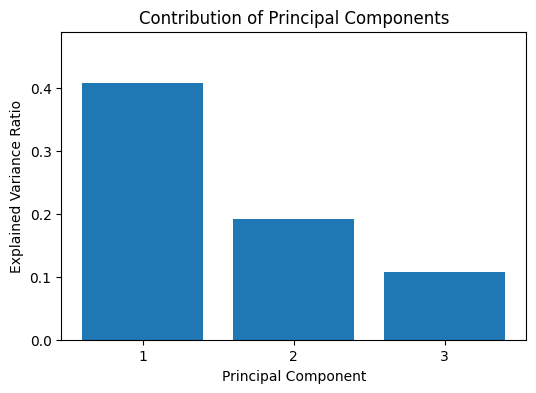

In [ ]:
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(pe_cluster)
# See explained variance
print(pca.explained_variance_ratio_)
print("The total explained variance is: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))


explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))
plt.bar(
    x=np.arange(1, len(explained_variance_ratio) + 1),
    height=explained_variance_ratio
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Contribution of Principal Components")
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1))
plt.ylim(0, max(explained_variance_ratio) * 1.2)

plt.show()

In [ ]:
pc_scores = pe_cluster @ pca.components_.T

# Compute correlation matrix between features and PCs
corr_matrix = np.corrcoef(pe_cluster.T, pc_scores.T)[
    :pe_cluster.shape[1],   # top block: features
    pe_cluster.shape[1]:    # right block: PCs
]

corr_df = pd.DataFrame(
    corr_matrix,
    index=pe_cluster.columns,
    columns=[f"PC{i+1}" for i in range(pc_scores.shape[1])]
)

print(corr_df)

                           PC1       PC2       PC3
age                   0.227575 -0.495482 -0.131254
gender                0.217975 -0.169697  0.167383
weight                0.743323 -0.365498  0.008642
height                0.676418 -0.474698 -0.320860
FEV1                  0.631898 -0.646500  0.246994
FEF2575               0.259694 -0.505826  0.196572
FVCpct                0.358793 -0.203518  0.498314
PEFpct                0.286623 -0.187828  0.870857
LC                    0.779439 -0.544208 -0.044805
TC                    0.271764  0.247866  0.159833
CR                   -0.320645  0.205342 -0.893115
PR                   -0.001286  0.455907 -0.047469
Sim_LungVol_Mean      0.828371 -0.483265 -0.028712
Sim_LungVol_Max       0.830192 -0.489925 -0.002467
Sim_LungVol_Std       0.825587 -0.510035  0.102188
Sim_TransP_Mean       0.575404 -0.449611 -0.605201
Sim_TransP_Max       -0.696508  0.342786  0.428364
Sim_TransP_Std       -0.715265  0.348156  0.436500
Sim_AlvP_PeakMax      0.287327 

In [ ]:
for pc in corr_df.columns:
    top3 = corr_df[pc].abs().sort_values(ascending=False)
    print(f"{pc}:")
    for feature in top3.index:
        print(f"  {feature} (correlation = {corr_df[pc].loc[feature]:.3f})")


PC1:
  LVP_std (correlation = 0.876)
  LVOF_std (correlation = 0.873)
  LVP_mean (correlation = 0.872)
  LVP_max (correlation = 0.865)
  AoP_max (correlation = 0.864)
  LVOF_min (correlation = -0.860)
  AoP_mean (correlation = 0.853)
  CO (correlation = 0.845)
  LVP_min (correlation = 0.840)
  Sim_LungVol_Max (correlation = 0.830)
  Sim_LungVol_Mean (correlation = 0.828)
  LVOF_max (correlation = 0.827)
  Sim_LungVol_Std (correlation = 0.826)
  AoP_min (correlation = 0.813)
  LVOF_mean (correlation = 0.795)
  BSA (correlation = 0.784)
  LC (correlation = 0.779)
  Sim_AlvFlow_Std (correlation = 0.757)
  weight (correlation = 0.743)
  Sim_AlvFlow_Mean (correlation = -0.720)
  Sim_TransP_Std (correlation = -0.715)
  Sim_TransP_Max (correlation = -0.697)
  height (correlation = 0.676)
  FEV1 (correlation = 0.632)
  Sim_DeadFlow_Std (correlation = 0.615)
  Sim_TransP_Mean (correlation = 0.575)
  AoP_std (correlation = 0.557)
  LVEDVi (correlation = 0.531)
  RVEDVi (correlation = 0.466)
  LV

In [ ]:
for pc in corr_df.columns:
    top3 = corr_df[pc].abs().sort_values(ascending=False).head(20)
    print(f"{pc}:")
    for feature in top3.index:
        print(f"  {feature} (correlation = {corr_df[pc].loc[feature]:.3f})")


PC1:
  LVP_std (correlation = 0.876)
  LVOF_std (correlation = 0.873)
  LVP_mean (correlation = 0.872)
  LVP_max (correlation = 0.865)
  AoP_max (correlation = 0.864)
  LVOF_min (correlation = -0.860)
  AoP_mean (correlation = 0.853)
  CO (correlation = 0.845)
  LVP_min (correlation = 0.840)
  Sim_LungVol_Max (correlation = 0.830)
  Sim_LungVol_Mean (correlation = 0.828)
  LVOF_max (correlation = 0.827)
  Sim_LungVol_Std (correlation = 0.826)
  AoP_min (correlation = 0.813)
  LVOF_mean (correlation = 0.795)
  BSA (correlation = 0.784)
  LC (correlation = 0.779)
  Sim_AlvFlow_Std (correlation = 0.757)
  weight (correlation = 0.743)
  Sim_AlvFlow_Mean (correlation = -0.720)
PC2:
  RVEDVi (correlation = 0.751)
  LVEDVi (correlation = 0.679)
  FEV1 (correlation = -0.647)
  RVESVi (correlation = 0.601)
  LC (correlation = -0.544)
  LVESVi (correlation = 0.542)
  Sim_AlvFlow_Std (correlation = -0.525)
  Sim_AlvFlow_Mean (correlation = 0.510)
  Sim_LungVol_Std (correlation = -0.510)
  FEF2575

## ***PCA Interpretation

**===== PC1 =====**
- AoP_max (+++)
- CO (++)
- Sim_LungVol_Max (++)
- Sim_LungVol_Mean (++)
- BSA (++)

Explanation: Larger patients exhibit higher cardiac output (CO) could be attributed to higher breaths in lungs (Sim_LungVol_Max)

Higher -> better overall function

Lower -> worse overall function

**===== PC2 =====**
- RVEDVi (+++)
- LVEDVi (+++)
- FEV1 (--)
- LC (--)

Explanation: Cardiac preload vs. ventilation tradeoff - model has good preload in the heart, but also has tradeoff in lung performance. Higher value of PC2 indicates better heart performance, lower PC2 represents better lung performance.

Higher -> worse lung performance, larger hearts (???)

Lower -> better lungs, average cardiac volumes

**===== PC3 =====**
- PEFpct (+++)
- Sim_AlvP_PeakMax (+++)
- Sim_AlvFlow_Max (++)
- Central Airway Resista (aka CR) (---)

Decreased small airway performance results in increased heart activity. Higher PC3 implies obstruction in small airways and increased heartrate in response to compensate for lower oxygen levels

Higher -> better lung performance

Lower -> worse lung performance

# Clustering

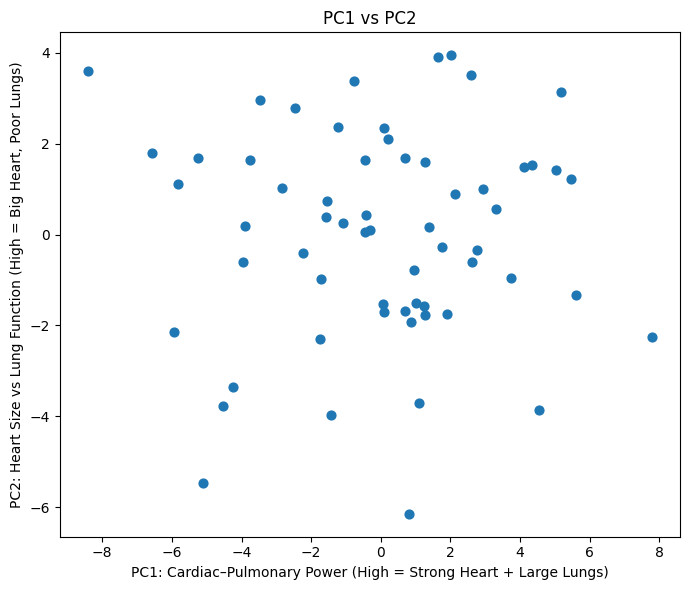

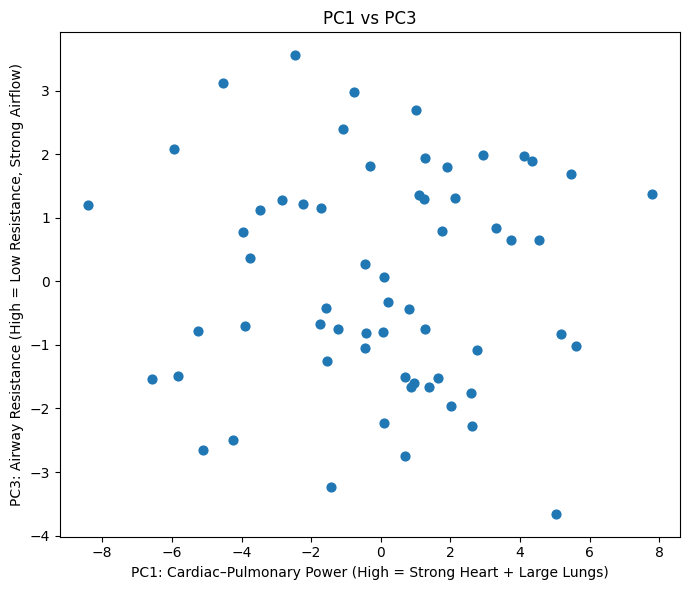

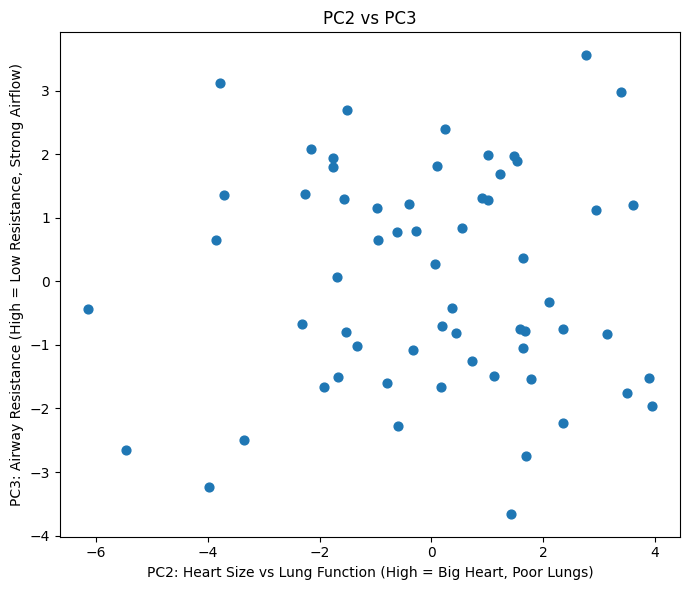

In [ ]:
# --- PC1 vs PC2 ---
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=40)
plt.xlabel("PC1: Cardiac–Pulmonary Power (High = Strong Heart + Large Lungs)")
plt.ylabel("PC2: Heart Size vs Lung Function (High = Big Heart, Poor Lungs)")
plt.title("PC1 vs PC2")
plt.tight_layout()
plt.show()

# --- PC1 vs PC3 ---
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 2], s=40)
plt.xlabel("PC1: Cardiac–Pulmonary Power (High = Strong Heart + Large Lungs)")
plt.ylabel("PC3: Airway Resistance (High = Low Resistance, Strong Airflow)")
plt.title("PC1 vs PC3")
plt.tight_layout()
plt.show()

# --- PC2 vs PC3 ---
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 1], X_pca[:, 2], s=40)
plt.xlabel("PC2: Heart Size vs Lung Function (High = Big Heart, Poor Lungs)")
plt.ylabel("PC3: Airway Resistance (High = Low Resistance, Strong Airflow)")
plt.title("PC2 vs PC3")
plt.tight_layout()
plt.show()


# Clustering Methods

## Finding Optimal Value of k

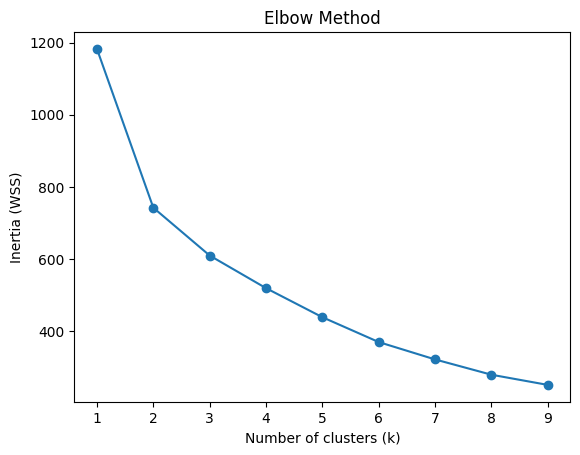

[1182.767379418635,
 742.0932095859521,
 609.3434166628613,
 518.7847400329267,
 438.13088534166724,
 369.12727797522757,
 320.9179460099105,
 278.4847098951724,
 250.22640109569676]

In [ ]:
# Elbow method

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)  # use your 3 PCs
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WSS)")
plt.title("Elbow Method")
plt.show()
inertia

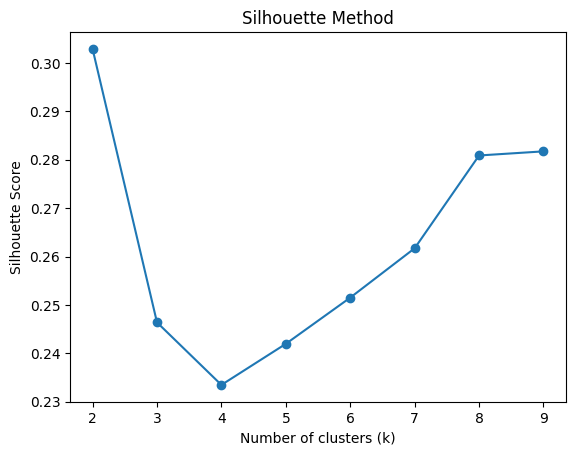

[np.float64(0.3029149565489897),
 np.float64(0.24638496407837934),
 np.float64(0.23345813280472116),
 np.float64(0.2419476288240307),
 np.float64(0.2515006506674989),
 np.float64(0.2617058093585777),
 np.float64(0.28088952479217294),
 np.float64(0.2817381370008027)]

In [ ]:
# Sihoutte Score (Separation + Compactnestt)
sil = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sil.append(silhouette_score(X_pca, labels))

plt.plot(K, sil, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()
sil

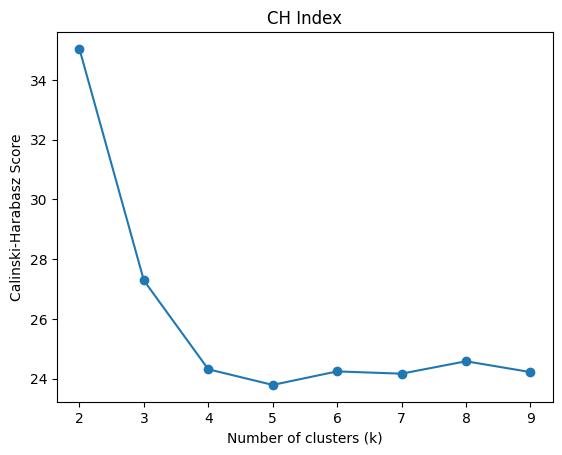

[np.float64(35.0357282404387),
 np.float64(27.29051379760478),
 np.float64(24.31773561328687),
 np.float64(23.794056218949073),
 np.float64(24.246490709034337),
 np.float64(24.170181185314547),
 np.float64(24.585592664153438),
 np.float64(24.224127959946696)]

In [ ]:
ch_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    ch_scores.append(calinski_harabasz_score(X_pca, labels))

plt.plot(K, ch_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("CH Index")
plt.show()

ch_scores


## K-Means

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)
df_pca_kmeans = pd.DataFrame(X_pca, columns=['PC1','PC2','PC3'])
df_pca_kmeans['cluster'] = clusters

In [40]:
fig = go.Figure()

point_colors = {
    0: "red",
    1: "green",
    2: "blue"
}

colors = {0: "rgba(255,0,0,255)",
          1: "rgba(0,255,0,255)",
          2: "rgba(0,0,255,255)"}

# Add point scatter
fig.add_trace(go.Scatter3d(
    x=df_pca_kmeans["PC1"],
    y=df_pca_kmeans["PC2"],
    z=df_pca_kmeans["PC3"],
    mode="markers",
    marker=dict(
    size=4,
    color=df_pca_kmeans["cluster"].map(point_colors)
),
    name="Points"
))

# Add convex hull for each cluster
for c in df_pca_kmeans["cluster"].unique():
    points = df_pca_kmeans[df_pca_kmeans["cluster"] == c][["PC1","PC2","PC3"]].values

    if len(points) >= 4:  # convex hull needs >=4 points
        hull = ConvexHull(points)
        vertices = hull.vertices

        fig.add_trace(go.Mesh3d(
            x=points[vertices, 0],
            y=points[vertices, 1],
            z=points[vertices, 2],
            opacity=0.2,
            color=colors[c],
            name=f"Cluster {c} Hull"
        ))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1: Cardiac–Pulmonary Power",
        yaxis_title="PC2: Heart Size vs Lung Func.",
        zaxis_title="PC3: Airway Res."
    ),
    width=900,
    height=800
)

fig.show()


- Cluster 0: strong overall function with lungs leading
- Cluster 1: weak overall function (small or underperforming heart + lungs)
- Cluster 2: strong overall function with heart compensating for lungs

## Agglomerative Clustering

In [ ]:
agg = AgglomerativeClustering(
    n_clusters=3,        # same as K-means choice
    linkage='ward'       # Ward is best for continuous data + PCA
)

clusters = agg.fit_predict(X_pca)

# Build the PCA dataframe with cluster labels
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['cluster'] = clusters

df_pca.head()

,PC1,PC2,PC3,cluster
0,5.043499,1.416873,-3.657547,0
1,0.090448,2.348193,-2.235542,2
2,5.162555,3.138667,-0.824155,0
3,2.937973,1.007510,1.982020,0
4,2.026626,3.944908,-1.964211,0


In [ ]:
fig = go.Figure()

colors = {0: "rgba(255,0,0,0.3)",
          1: "rgba(0,255,0,0.3)",
          2: "rgba(0,0,255,0.3)"}

# Add point scatter
fig.add_trace(go.Scatter3d(
    x=df_pca["PC1"],
    y=df_pca["PC2"],
    z=df_pca["PC3"],
    mode="markers",
    marker=dict(size=4, color=df_pca["cluster"], colorscale="Viridis"),
    name="Points"
))

# Add convex hull for each cluster
for c in df_pca["cluster"].unique():
    points = df_pca[df_pca["cluster"] == c][["PC1","PC2","PC3"]].values

    if len(points) >= 4:  # convex hull needs >=4 points
        hull = ConvexHull(points)
        vertices = hull.vertices

        fig.add_trace(go.Mesh3d(
            x=points[vertices, 0],
            y=points[vertices, 1],
            z=points[vertices, 2],
            opacity=0.2,
            color=colors[c],
            name=f"Cluster {c} Hull"
        ))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1: Cardiac–Pulmonary Power (High = Strong Heart + Large Lungs)",
        yaxis_title="PC2: Heart Size vs Lung Function (High = Big Heart, Poor Lungs)",
        zaxis_title="PC3: Airway Resistance (High = Low Resistance, Strong Airflow)"
    ),
    width=900,
    height=800
)

fig.show()


K Means better separates clusters

# Hypothesis Testing

BSA, weight, height, FEV1, PEFpct, RVEDVi, LVEDVi RVESVi

In [ ]:
df_pe_cluster = pe.merge(df_pca_kmeans, left_index=True, right_index=True)
df_pe_cluster.columns

Index(['patientIndex', 'age', 'gender', 'weight', 'height', 'FEV1', 'FEF2575',
       'FVCpct', 'PEFpct', 'LC', 'TC', 'CR', 'PR', 'Cs', 'Sim_LungVol_Mean',
       'Sim_LungVol_Max', 'Sim_LungVol_Std', 'Sim_TransP_Mean',
       'Sim_TransP_Max', 'Sim_TransP_Std', 'Sim_AlvP_PeakMax',
       'Sim_AlvP_PeakMin', 'Sim_Flow_PeakMax', 'Sim_Flow_Std',
       'Sim_DeadFlow_PeakMax', 'Sim_DeadFlow_Std', 'Sim_AlvFlow_Max',
       'Sim_AlvFlow_Mean', 'Sim_AlvFlow_Std', 'PtKey', 'BSA', 'HR', 'tc',
       'LVEDVi', 'LVESVi', 'RVEDVi', 'RVESVi', 'SV', 'CO', 'AoP_mean',
       'AoP_max', 'AoP_min', 'AoP_std', 'LVP_mean', 'LVP_max', 'LVP_min',
       'LVP_std', 'LVOF_mean', 'LVOF_max', 'LVOF_min', 'LVOF_std', 'PC1',
       'PC2', 'PC3', 'cluster'],
      dtype='object')

In [ ]:
df_pe_cluster['cluster'].value_counts()

,count
cluster,
2,24
0,19
1,18


In [ ]:
labels = df_pe_cluster["cluster"]

Plotting

In [ ]:
TITLE_FS = 24
LABEL_FS = 20
TICK_FS = 18

# Lighter colors as RGBA tuples (R,G,B,A) with values 0–1
box_colors = {
    0: (1.0, 0.4, 0.4, 0.6),  # light red
    1: (0.4, 1.0, 0.4, 0.6),  # light green
    2: (0.4, 0.4, 1.0, 0.6)   # light blue
}

## Principal Component #1

In [ ]:
cols = ["BSA"]

results = {}

for col in cols:
    groups = [df_pe_cluster.loc[labels == g, col].dropna() for g in labels.unique()]

    # Kruskal–Wallis test
    stat, p = kruskal(*groups)
    results[col] = (stat, p)

for col, (stat, p) in results.items():
    print(col, stat, p)

BSA 32.656225273812545 8.10570477545309e-08


In [ ]:
labels = df_pe_cluster["cluster"]

for col in cols:
    data = df_pe_cluster[[col, "cluster"]].dropna()
    # Dunn's test with Bonferroni correction
    dunn_res = sp.posthoc_dunn(data, val_col=col, group_col="cluster", p_adjust='bonferroni')
    print(f"\nDunn post-hoc for {col}:\n", dunn_res)



Dunn post-hoc for BSA:
               0         1             2
0  1.000000e+00  1.000000  3.501037e-07
1  1.000000e+00  1.000000  6.922606e-05
2  3.501037e-07  0.000069  1.000000e+00


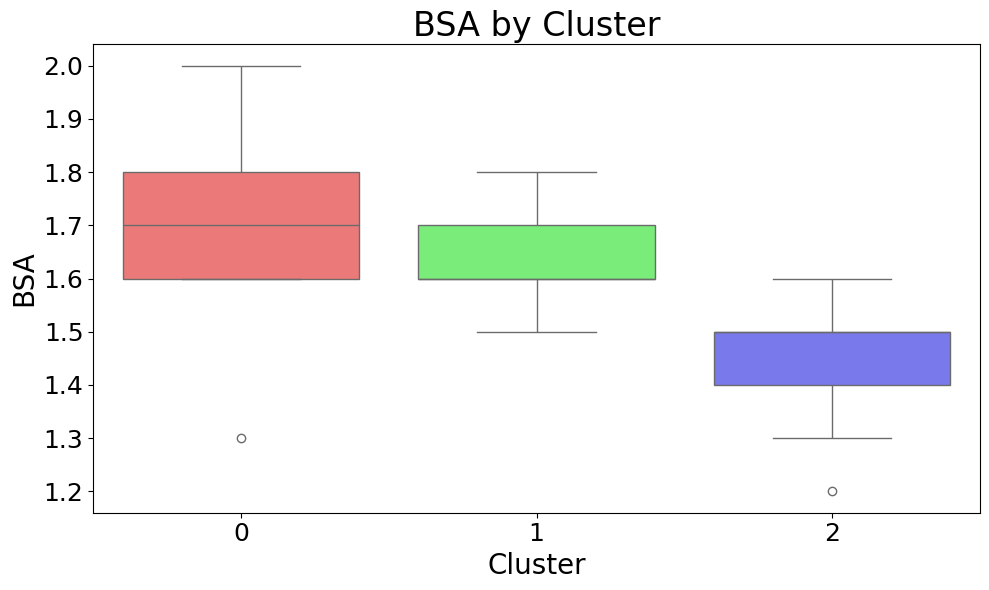

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))

# BSA boxplot
sns.boxplot(
    x="cluster", y="BSA", data=df_pe_cluster,
    hue="cluster", palette=box_colors, legend=False, ax=ax
)

ax.set_title("BSA by Cluster", fontsize=TITLE_FS)
ax.set_xlabel("Cluster", fontsize=LABEL_FS)
ax.set_ylabel("BSA", fontsize=LABEL_FS)
ax.tick_params(axis='both', labelsize=TICK_FS)

plt.tight_layout()
plt.show()


## Principal Component #2

In [ ]:
cols = ['RVEDVi', 'LVEDVi', 'FEV1']

results = {}

for col in cols:
    groups = [df_pe_cluster.loc[labels == g, col].dropna() for g in labels.unique()]

    # Kruskal–Wallis test
    stat, p = kruskal(*groups)
    results[col] = (stat, p)

for col, (stat, p) in results.items():
    print(col, stat, p)

RVEDVi 29.18155097405578 4.605817433440354e-07
LVEDVi 28.206316067837175 7.500259478219495e-07
FEV1 27.768769387370682 9.334441599609046e-07


In [ ]:
for col in cols:
    data = df_pe_cluster[[col, "cluster"]].dropna()
    # Dunn's test with Bonferroni correction
    dunn_res = sp.posthoc_dunn(data, val_col=col, group_col="cluster", p_adjust='bonferroni')
    print(f"\nDunn post-hoc for {col}:\n", dunn_res)



Dunn post-hoc for RVEDVi:
           0         1        2
0  1.000000  0.000004  1.00000
1  0.000004  1.000000  0.00001
2  1.000000  0.000010  1.00000

Dunn post-hoc for LVEDVi:
           0         1         2
0  1.000000  0.000059  1.000000
1  0.000059  1.000000  0.000002
2  1.000000  0.000002  1.000000

Dunn post-hoc for FEV1:
               0         1             2
0  1.000000e+00  0.002347  5.491032e-07
1  2.346681e-03  1.000000  3.332165e-01
2  5.491032e-07  0.333216  1.000000e+00


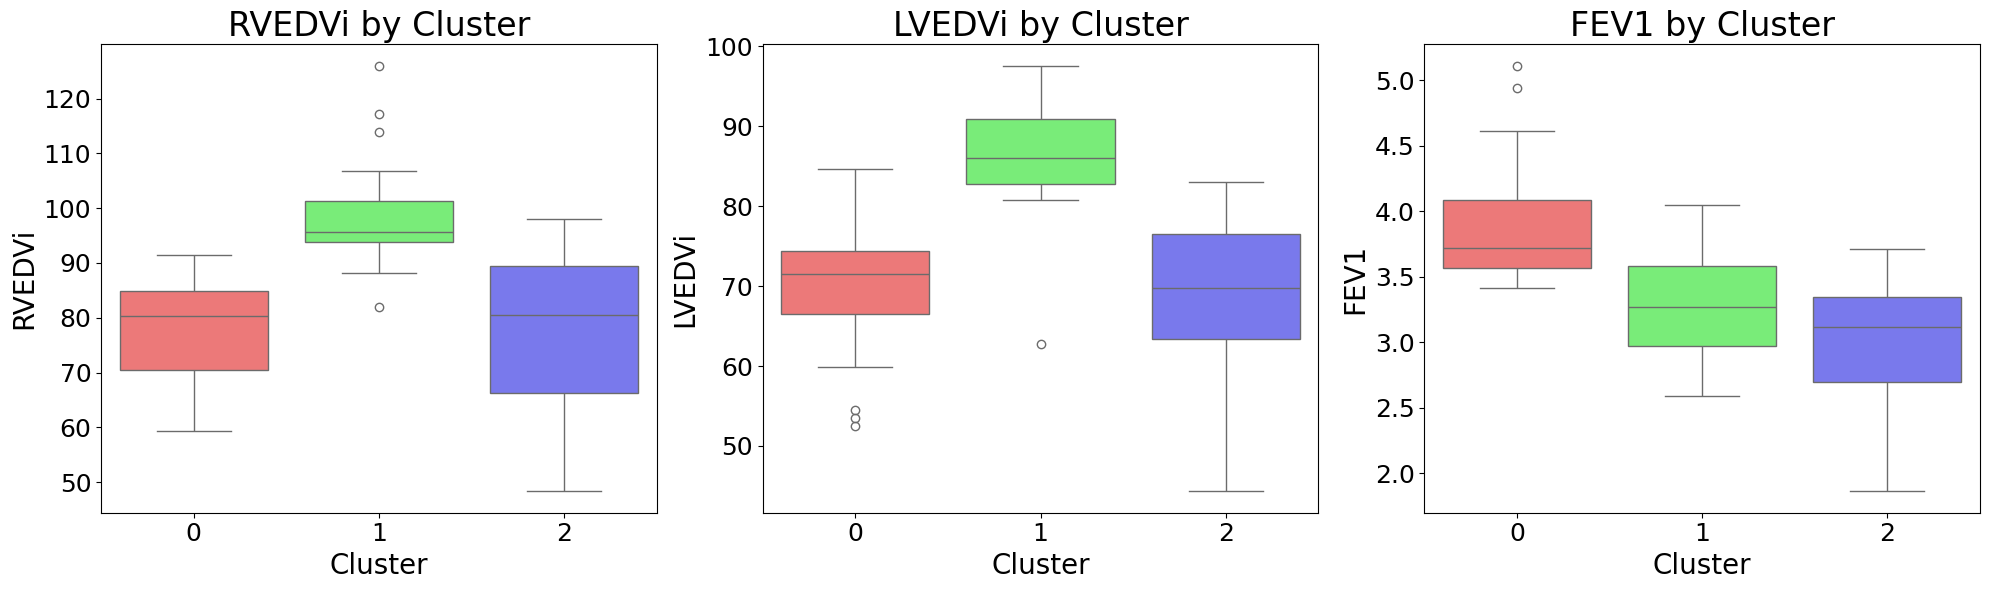

In [ ]:
cols = ['RVEDVi', 'LVEDVi', 'FEV1']
fig, axes = plt.subplots(1, len(cols), figsize=(20,6))

for i, col in enumerate(cols):
    sns.boxplot(
        x="cluster", y=col, data=df_pe_cluster,
        hue="cluster", palette=box_colors, legend=False, ax=axes[i]
    )
    axes[i].set_title(f"{col} by Cluster", fontsize=TITLE_FS)
    axes[i].set_xlabel("Cluster", fontsize=LABEL_FS)
    axes[i].set_ylabel(col, fontsize=LABEL_FS)
    axes[i].tick_params(axis='both', labelsize=TICK_FS)

plt.tight_layout()
plt.show()


## Principal Component #3

In [ ]:
cols = ['PEFpct']

results = {}

for col in cols:
    groups = [df_pe_cluster.loc[labels == g, col].dropna() for g in labels.unique()]

    # Kruskal–Wallis test
    stat, p = kruskal(*groups)
    results[col] = (stat, p)

for col, (stat, p) in results.items():
    print(col, stat, p)

PEFpct 2.0838343907211843 0.3527776894531596


# Conclusions

**========== Group 0 ==========**

Distinctly different in FEV1

- High BSA, but decreased RVEDVi/LVEDVi, but high FEV1

- This cluster exhibits patients with larger body surface area (could also mean larger chest cavity), the lung performance is best out of this group, but also has the lower end of heart volumes.

_This could mean that this set of patients has compression more in the heart and less so on the lungs, makes sense because the heart is typically the closer organ to chest wall compression_

**========== Group 1 ==========**

Distinctly different in BSA

- This cluster exhibits patients with smallest body surface area (BSA), low cardiac volumes, and low lung performance

_We could attribute both decreased performances in heart and lung due to nature of a smaller chest cavity, causing significant compression on BOTH heart and lungs_

**========== Group 2 ==========**

Distinctly different in RVEDVi and LVEDVi

- This cluster exhibits high body surface area, high cardiac volumes, but moderate lung function
- Essentially near opposite of Group 0, where there is moderate/high body surface area, but worse lung performance

_We suggest that both declines in performance could be due to additional factors outside of the analysis (e.x. specific compression angle)_
